# VisionQC experiment: train, evaluate, export, and inspect

Run the cells from top to bottom. The notebook downloads the MVTec AD bottle category, trains PatchCore on a reproducible sample of normal images, evaluates it, exports and reloads the model, then exercises the inspection API. It uses the available CPU/GPU and keeps generated files under `experiment_run/`.

In [2]:
%pip install -q "anomalib==2.6.2" kagglehub matplotlib opencv-python-headless fastapi python-multipart httpx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
os.environ["TRUST_REMOTE_CODE"] = "1"

import base64
import random
import shutil
import sqlite3
import time
from pathlib import Path

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
from anomalib.data import Folder
from anomalib.deploy import ExportType, TorchInferencer
from anomalib.engine import Engine
from anomalib.models import Patchcore

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_DIR = Path.cwd() / "experiment_run"
DATA_ROOT = RUN_DIR / "bottle"
EXPORT_ROOT = RUN_DIR / "exported"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Experiment files: {RUN_DIR.resolve()}")

c:\Users\Karan Sharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
c:\Users\Karan Sharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\Karan Sharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\anomalib\models\image\dinomaly\components\layers.py:22: FutureWarning: The anomalib.models.components.dinov2 package is deprecated and will be removed in a future release. Please use the timm-based feature extractor instead: anomalib.models.components.feature_extractors.TimmFeatureExtractor
  from anomalib.models.components.dinov2.layers import Attention, DropPath, LayerScale, 

Device: cpu
Experiment files: C:\Users\Karan Sharma\Documents\GitHub\vision-qc\backend\experiment_run


In [4]:
download_path = Path(kagglehub.dataset_download("ipythonx/mvtec-ad")).resolve()
candidates = [download_path, *download_path.rglob("bottle")]
bottle_root = next(
    (candidate for candidate in candidates
     if (candidate / "train" / "good").is_dir()
     and (candidate / "test" / "good").is_dir()),
    None,
)
if bottle_root is None:
    raise FileNotFoundError(
        f"Could not find bottle/train/good and bottle/test/good under {download_path}. "
        "Check the Kaggle dataset download and its directory layout."
    )

train_images = sorted((bottle_root / "train" / "good").glob("*.png"))
if len(train_images) < 10:
    raise ValueError(f"Expected at least 10 normal training images; found {len(train_images)}.")
print(f"Dataset: {bottle_root}")
print(f"Available normal training images: {len(train_images)}")

Dataset: C:\Users\Karan Sharma\.cache\kagglehub\datasets\ipythonx\mvtec-ad\versions\2\bottle
Available normal training images: 209


In [5]:
TRAIN_IMAGE_COUNT = min(25, len(train_images))
sampled_images = random.Random(42).sample(train_images, TRAIN_IMAGE_COUNT)
normal_train_dir = DATA_ROOT / "train" / "good"
normal_train_dir.mkdir(parents=True, exist_ok=True)
for index, source in enumerate(sampled_images):
    shutil.copy2(source, normal_train_dir / f"{index:03d}.png")
shutil.copytree(bottle_root / "test", DATA_ROOT / "test", dirs_exist_ok=True)

defect_types = sorted(
    folder.name for folder in (DATA_ROOT / "test").iterdir()
    if folder.is_dir() and folder.name != "good"
)
if not defect_types or not list((DATA_ROOT / "test" / "good").glob("*.png")):
    raise FileNotFoundError("The copied test set must contain good images and defect folders.")
print(f"Copied {TRAIN_IMAGE_COUNT} normal training images")
print(f"Test categories: good, {', '.join(defect_types)}")

Copied 25 normal training images
Test categories: good, broken_large, broken_small, contamination


In [6]:
datamodule = Folder(
    name="bottle",
    root=DATA_ROOT,
    normal_dir="train/good",
    abnormal_dir=[f"test/{name}" for name in defect_types],
    normal_test_dir="test/good",
    num_workers=0,
)
model = Patchcore()
engine = Engine(enable_progress_bar=False, default_root_dir=RUN_DIR / "results")
engine.fit(model=model, datamodule=datamodule)
test_metrics = engine.test(model=model, datamodule=datamodule)
print("Test metrics:", test_metrics)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\Karan Sharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightning\pytorch\core\optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │ 24.9 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99.450                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 174                                                                                          
Total FLOPs: 0

c:\Users\Karan Sharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Karan Sharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Karan Sharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Karan Sharma\AppData\Local\Programs\Python\Python313\Lib\site-package

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │            1.0            │
│       image_F1Score       │    0.9677419066429138     │
└───────────────────────────┴───────────────────────────┘

Test metrics: [{'image_AUROC': 1.0, 'image_F1Score': 0.9677419066429138}]


In [7]:
engine.export(
    model=model,
    export_type=ExportType.TORCH,
    export_root=EXPORT_ROOT,
)
weight_files = sorted(EXPORT_ROOT.rglob("model.pt"))
if not weight_files:
    raise FileNotFoundError(f"Model export did not produce model.pt under {EXPORT_ROOT}.")
WEIGHT_PATH = weight_files[0]
inferencer = TorchInferencer(path=WEIGHT_PATH, device=DEVICE)
print(f"Exported and reloaded model: {WEIGHT_PATH}")

Exported and reloaded model: c:\Users\Karan Sharma\Documents\GitHub\vision-qc\backend\experiment_run\exported\weights\torch\model.pt


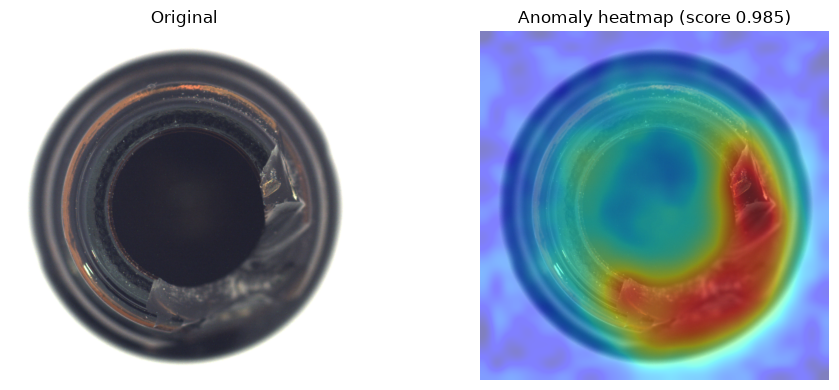

In [8]:
def to_numpy(value):
    if hasattr(value, "detach"):
        value = value.detach().cpu().numpy()
    return np.asarray(value)

def predict_score(image_path):
    prediction = inferencer.predict(image=str(image_path))
    score = float(to_numpy(prediction.pred_score).squeeze())
    if not np.isfinite(score):
        raise ValueError(f"Model returned a non-finite score for {image_path}; retrain and export the model.")
    return score

sample_image = next((DATA_ROOT / "test" / defect_types[0]).glob("*.png"), None)
if sample_image is None:
    raise FileNotFoundError(f"No test images found in test/{defect_types[0]}.")
prediction = inferencer.predict(image=str(sample_image))
original = plt.imread(sample_image)
anomaly_map = to_numpy(prediction.anomaly_map).squeeze()
anomaly_map = cv2.resize(anomaly_map, (original.shape[1], original.shape[0]))
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(original)
plt.imshow(anomaly_map, cmap="jet", alpha=0.5)
plt.title(f"Anomaly heatmap (score {predict_score(sample_image):.3f})")
plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
test_root = DATA_ROOT / "test"
good_images = sorted((test_root / "good").glob("*.png"))
bad_images = [
    image
    for category in defect_types
    for image in sorted((test_root / category).glob("*.png"))
]
if not good_images or not bad_images:
    raise ValueError("Cannot compare normal and anomalous scores: one test group is empty.")
good_scores = [predict_score(image) for image in good_images]
bad_scores = [predict_score(image) for image in bad_images]
print("Good: min %.3f | max %.3f | mean %.3f" % (min(good_scores), max(good_scores), np.mean(good_scores)))
print("Defect: min %.3f | max %.3f | mean %.3f" % (min(bad_scores), max(bad_scores), np.mean(bad_scores)))

Good: min 0.224 | max 0.349 | mean 0.280
Defect: min 0.485 | max 1.000 | mean 0.846


In [10]:
threshold = float(np.clip(np.percentile(good_scores, 99), 0.01, 0.99))

def confidence_of(score, threshold_value):
    if not 0 < threshold_value < 1:
        return 50.0
    if score <= threshold_value:
        return round((threshold_value - score) / threshold_value * 100, 1)
    return round((score - threshold_value) / (1 - threshold_value) * 100, 1)

print(f"Normal-score 99th-percentile threshold: {threshold:.3f}")
for score in [good_scores[0], bad_scores[0]]:
    verdict = "FAIL" if score > threshold else "PASS"
    print(f"score={score:.3f} -> {verdict} | confidence={confidence_of(score, threshold):.1f}%")

Normal-score 99th-percentile threshold: 0.346
score=0.270 -> PASS | confidence=22.0%
score=0.985 -> FAIL | confidence=97.8%


In [11]:
from fastapi import FastAPI, File, HTTPException, UploadFile
from fastapi.testclient import TestClient
from pydantic import BaseModel, Field

app = FastAPI(title="VisionQC Experiment API")
db = sqlite3.connect(":memory:", check_same_thread=False)
db.execute("CREATE TABLE log(ts REAL, score REAL, result TEXT)")
db.commit()

class ThresholdUpdate(BaseModel):
    value: float = Field(ge=0, le=1)

@app.post("/inspect")
async def inspect(file: UploadFile = File(...)):
    image_bytes = await file.read()
    image = cv2.imdecode(np.frombuffer(image_bytes, np.uint8), cv2.IMREAD_COLOR)
    if image is None:
        raise HTTPException(status_code=400, detail="Uploaded file is not a readable image.")
    result = inferencer.predict(image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    score = float(to_numpy(result.pred_score).squeeze())
    if not np.isfinite(score):
        raise HTTPException(status_code=500, detail="Model returned a non-finite score; retrain and export it.")
    verdict = "FAIL" if score > threshold else "PASS"
    heatmap = cv2.resize(to_numpy(result.anomaly_map).squeeze(), (image.shape[1], image.shape[0]))
    if not np.isfinite(heatmap).all():
        raise HTTPException(status_code=500, detail="Model returned a non-finite anomaly map.")
    heatmap = (255 * (heatmap - heatmap.min()) / (np.ptp(heatmap) + 1e-8)).astype(np.uint8)
    overlay = cv2.addWeighted(image, 0.5, cv2.applyColorMap(heatmap, cv2.COLORMAP_JET), 0.5, 0)
    ok, encoded = cv2.imencode(".png", overlay)
    if not ok:
        raise RuntimeError("Could not encode the inspection heatmap.")
    db.execute("INSERT INTO log VALUES (?, ?, ?)", (time.time(), score, verdict))
    db.commit()
    return {
        "score": round(score, 3),
        "result": verdict,
        "confidence": confidence_of(score, threshold),
        "threshold": threshold,
        "heatmap_b64": "data:image/png;base64," + base64.b64encode(encoded.tobytes()).decode("ascii"),
    }

@app.get("/threshold")
def get_threshold():
    return {"threshold": threshold}

@app.put("/threshold")
def set_threshold(update: ThresholdUpdate):
    global threshold
    threshold = update.value
    return {"threshold": threshold}

@app.get("/stats")
def stats():
    day_start = time.time() - (time.time() % 86400)
    total, rejected = db.execute(
        "SELECT COUNT(*), SUM(CASE WHEN result='FAIL' THEN 1 ELSE 0 END) FROM log WHERE ts >= ?",
        (day_start,),
    ).fetchone()
    total, rejected = total or 0, rejected or 0
    return {
        "total": total,
        "passed": total - rejected,
        "rejected": rejected,
        "rejection_rate": round(100 * rejected / total, 1) if total else 0.0,
    }

print("API routes registered:", sorted(route.path for route in app.routes if hasattr(route, "methods")))

API routes registered: ['/docs', '/docs/oauth2-redirect', '/inspect', '/openapi.json', '/redoc', '/stats', '/threshold', '/threshold']


In [12]:
client = TestClient(app)
sample_bytes = sample_image.read_bytes()
inspection = client.post(
    "/inspect",
    files={"file": (sample_image.name, sample_bytes, "image/png")},
)
inspection.raise_for_status()
inspection_result = inspection.json()
assert inspection_result["result"] in {"PASS", "FAIL"}
assert inspection_result["heatmap_b64"].startswith("data:image/png;base64,")
assert client.get("/threshold").status_code == 200
stats_result = client.get("/stats").json()
assert stats_result["total"] == 1
print("Inspection response:", {key: value for key, value in inspection_result.items() if key != "heatmap_b64"})
print("Stats response:", stats_result)
print("Experiment completed successfully.")

Inspection response: {'score': 0.985, 'result': 'FAIL', 'confidence': 97.8, 'threshold': 0.346366516649723}
Stats response: {'total': 1, 'passed': 0, 'rejected': 1, 'rejection_rate': 100.0}
Experiment completed successfully.
